# Clasificación Multiclase — Sign Language MNIST (Lenguaje de Señas)

**Estudiante:** Isabel Romero Caspary

## Descripción del Dataset

El dataset **Sign Language MNIST** es una versión del MNIST original adaptada para el lenguaje de señas americano (ASL). Cada imagen es de 28×28 píxeles en escala de grises, representando una de las 24 letras del alfabeto que se pueden expresar con la mano estática (se excluyen J y Z que requieren movimiento).

- **Número de ejemplos:** m ≥ 5.000 (train: ~27.455, test: ~7.172)
- **Número de propiedades:** n = 784 (28 × 28 píxeles) > 100
- **Clases:** 24 letras del alfabeto ASL (0–23, excluyendo J=9 y Z=25)
- **Tipo:** Dataset multimodal (imágenes)

El objetivo es entrenar un modelo de **regresión logística one-vs-all** para reconocer letras del lenguaje de señas a partir de los píxeles de la imagen.

## 1. Montaje de Google Drive y carga de librerías

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Manipulación de directorios y rutas
import os

# Cálculo científico y vectorial
import numpy as np

# Preprocesamiento con Pandas
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot
import matplotlib.pyplot as plt

# Módulo de optimización
from scipy import optimize

# Gráficos en el cuaderno
%matplotlib inline

## 2. Carga y Preprocesamiento con Pandas

El dataset Sign Language MNIST se distribuye en dos archivos CSV:
- `sign_mnist_train.csv`: datos de entrenamiento (~27.455 filas)
- `sign_mnist_test.csv`: datos de prueba (~7.172 filas)

Cada fila tiene: columna `label` (clase) + 784 columnas `pixel1` a `pixel784`.

Se utiliza **Pandas** para:
- Leer ambos archivos CSV
- Combinar en un único DataFrame para garantizar el split 80/20 propio
- Verificar y balancear las clases
- Separar características (X) y etiquetas (y)

In [6]:
# Ruta al dataset en Google Drive
ruta_train = '/content/drive/MyDrive/SIS420/archive/sign_mnist_train/sign_mnist_train.csv'
ruta_test  = '/content/drive/MyDrive/SIS420/archive/sign_mnist_test/sign_mnist_test.csv'

# Leer ambos archivos con Pandas
df_train = pd.read_csv(ruta_train)
df_test  = pd.read_csv(ruta_test)

# Combinar para hacer nuestro propio split 80/20
df = pd.concat([df_train, df_test], ignore_index=True)

print(f'Dimensiones totales: {df.shape}')
print(f'Columnas: {df.columns[:5].tolist()} ... (total {len(df.columns)})')
print(f'Distribución de clases:\n{df["label"].value_counts().sort_index()}')

Dimensiones totales: (34627, 785)
Columnas: ['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4'] ... (total 785)
Distribución de clases:
label
0     1457
1     1442
2     1454
3     1441
4     1455
5     1451
6     1438
7     1449
8     1450
10    1445
11    1450
12    1449
13    1442
14    1442
15    1435
16    1443
17    1438
18    1445
19    1434
20    1427
21    1428
22    1431
23    1431
24    1450
Name: count, dtype: int64


In [7]:
# Balanceo de clases: igual número de ejemplos por letra
min_ejemplos = df['label'].value_counts().min()
print(f'Mínimo de ejemplos por clase: {min_ejemplos}')

df_balanceado = df.groupby('label').apply(
    lambda x: x.sample(n=min_ejemplos, random_state=42)
).reset_index(drop=True)

print(f'Dimensiones tras balanceo: {df_balanceado.shape}')
print(f'Distribución balanceada:\n{df_balanceado["label"].value_counts().sort_index()}')

Mínimo de ejemplos por clase: 1427
Dimensiones tras balanceo: (34248, 785)
Distribución balanceada:
label
0     1427
1     1427
2     1427
3     1427
4     1427
5     1427
6     1427
7     1427
8     1427
10    1427
11    1427
12    1427
13    1427
14    1427
15    1427
16    1427
17    1427
18    1427
19    1427
20    1427
21    1427
22    1427
23    1427
24    1427
Name: count, dtype: int64


/tmp/ipykernel_5028/803778729.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanceado = df.groupby('label').apply(


In [8]:
# Separar características y etiquetas
y_raw = df_balanceado['label'].values
X     = df_balanceado.drop(columns=['label']).values.astype(float)

# Re-etiquetar clases a 0, 1, 2, ..., K-1
clases_unicas = sorted(np.unique(y_raw))
mapeo = {cls: idx for idx, cls in enumerate(clases_unicas)}
y = np.array([mapeo[val] for val in y_raw])

num_labels = len(clases_unicas)
m, n = X.shape

print(f'Número de ejemplos (m): {m}')
print(f'Número de propiedades (n): {n}  [784 píxeles = 28×28]')
print(f'Número de clases: {num_labels}')

Número de ejemplos (m): 34248
Número de propiedades (n): 784  [784 píxeles = 28×28]
Número de clases: 24


## 3. Visualización de Muestras del Dataset

Se muestran ejemplos representativos de cada letra del lenguaje de señas para verificar que los datos fueron cargados correctamente.

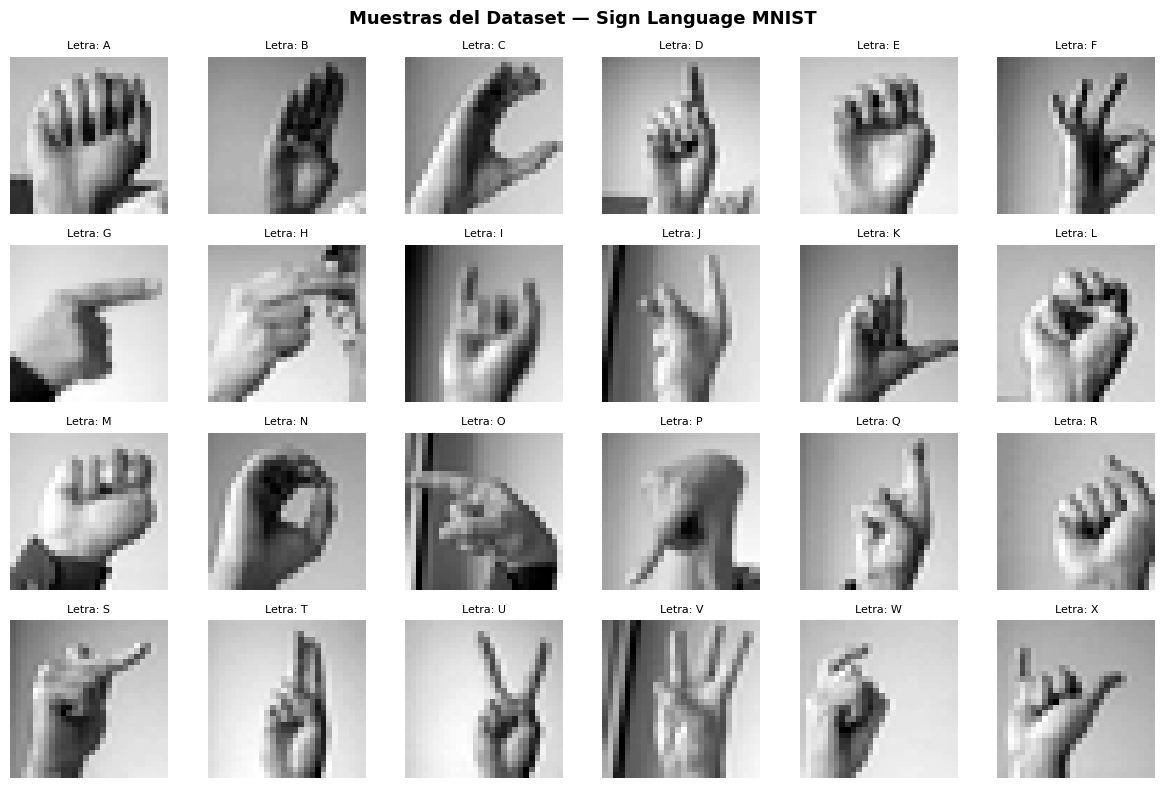

In [9]:
def displayData(X, labels=None, filas=4, cols=6, figsize=(12, 8)):
    letras = list('ABCDEFGHIJKLMNOPQRSTUVWXY')  # sin J ni Z
    fig, axes = plt.subplots(filas, cols, figsize=figsize)
    axes = axes.flatten()
    for i in range(min(filas * cols, len(X))):
        axes[i].imshow(X[i].reshape(28, 28), cmap='gray')
        if labels is not None:
            axes[i].set_title(f'Letra: {letras[labels[i]]}', fontsize=8)
        axes[i].axis('off')
    plt.suptitle('Muestras del Dataset — Sign Language MNIST', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Mostrar una muestra por clase
muestras_X = []
muestras_y = []
for c in range(num_labels):
    idx = np.where(y == c)[0][0]
    muestras_X.append(X[idx])
    muestras_y.append(c)

displayData(np.array(muestras_X), muestras_y, filas=4, cols=6)

## 4. División del Dataset: 80% Entrenamiento / 20% Prueba

Se divide aleatoriamente el dataset combinado. Los datos de prueba **no participan** en el entrenamiento del modelo.

In [10]:
np.random.seed(42)
indices = np.random.permutation(m)

corte = int(0.8 * m)
idx_train = indices[:corte]
idx_test  = indices[corte:]

X_train, y_train = X[idx_train], y[idx_train]
X_test,  y_test  = X[idx_test],  y[idx_test]

print(f'Ejemplos de entrenamiento: {X_train.shape[0]}')
print(f'Ejemplos de prueba:        {X_test.shape[0]}')

Ejemplos de entrenamiento: 27398
Ejemplos de prueba:        6850


## 5. Normalización de Características

Los valores de píxel originales están en el rango [0, 255]. Se aplica normalización dividiéndolos entre 255 para llevarlos al rango [0, 1], lo que mejora la estabilidad numérica del entrenamiento.

Alternativamente, se puede aplicar la normalización z-score. Aquí se usa la normalización por máximo (más natural para imágenes).

In [11]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # evitar división por cero en píxeles constantes
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train)
X_test_norm  = (X_test - mu) / sigma

print(f'X_train normalizado: {X_train_norm.shape}')
print(f'X_test  normalizado: {X_test_norm.shape}')

X_train normalizado: (27398, 784)
X_test  normalizado: (6850, 784)


## 6. Modelo de Regresión Logística One-vs-All

Se añadirá las siguientes funciones
* Función Sigmoide

* Función de Costo Regularizada
* Gradiente



In [12]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))

    temp = theta.copy()
    temp[0] = 0

    J = (1/m) * (-y.dot(np.log(h + 1e-10)) - (1 - y).dot(np.log(1 - h + 1e-10))) \
        + (lambda_ / (2*m)) * np.sum(temp**2)

    grad = (1/m) * X.T.dot(h - y) + (lambda_ / m) * temp

    return J, grad

## 7. Entrenamiento del Clasificador One-vs-All

Se entrena un clasificador logístico por cada una de las 24 clases (letras). La historia de costo es registrada en cada iteración para su visualización posterior.

In [ ]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    costos_por_clase = []

    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        y_c = (y == c).astype(float)

        historial = []
        def callback_fn(theta):
            J, _ = lrCostFunction(theta, X_b, y_c, lambda_)
            historial.append(J)

        options = {'maxiter': 100}
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X_b, y_c, lambda_),
            jac=True,
            method='CG',
            callback=callback_fn,
            options=options
        )

        all_theta[c] = res.x
        costos_por_clase.append(historial)

        letras = list('ABCDEFGHIJKLMNOPQRSTUVWXY')
        print(f'Clase {c} ({letras[c]}): costo final = {res.fun:.4f}')

    return all_theta, costos_por_clase

lambda_ = 0.1
all_theta, costos_por_clase = oneVsAll(X_train_norm, y_train, num_labels, lambda_)
print(f'\nForma de all_theta: {all_theta.shape}')

Clase 0 (A): costo final = 0.0003
Clase 1 (B): costo final = 0.0004
Clase 2 (C): costo final = 0.0003
Clase 3 (D): costo final = 0.0048
Clase 4 (E): costo final = 0.0018
Clase 5 (F): costo final = 0.0055
Clase 6 (G): costo final = 0.0055
Clase 7 (H): costo final = 0.0023
Clase 8 (I): costo final = 0.0068
Clase 9 (J): costo final = 0.0015
Clase 10 (K): costo final = 0.0029
Clase 11 (L): costo final = 0.0037
Clase 12 (M): costo final = 0.0127
Clase 13 (N): costo final = 0.0020
Clase 14 (O): costo final = 0.0014
Clase 15 (P): costo final = 0.0014
Clase 16 (Q): costo final = 0.0043
Clase 17 (R): costo final = 0.0052
Clase 18 (S): costo final = 0.0133
Clase 19 (T): costo final = 0.0274
Clase 20 (U): costo final = 0.0124
Clase 21 (V): costo final = 0.0183
Clase 22 (W): costo final = 0.0064
Clase 23 (X): costo final = 0.0009

Forma de all_theta: (24, 785)


## 8. Gráfica de Costo por Clase

La evolución descendente del costo en cada clasificador binario confirma que el algoritmo de optimización converge correctamente hacia un mínimo de la función de pérdida.

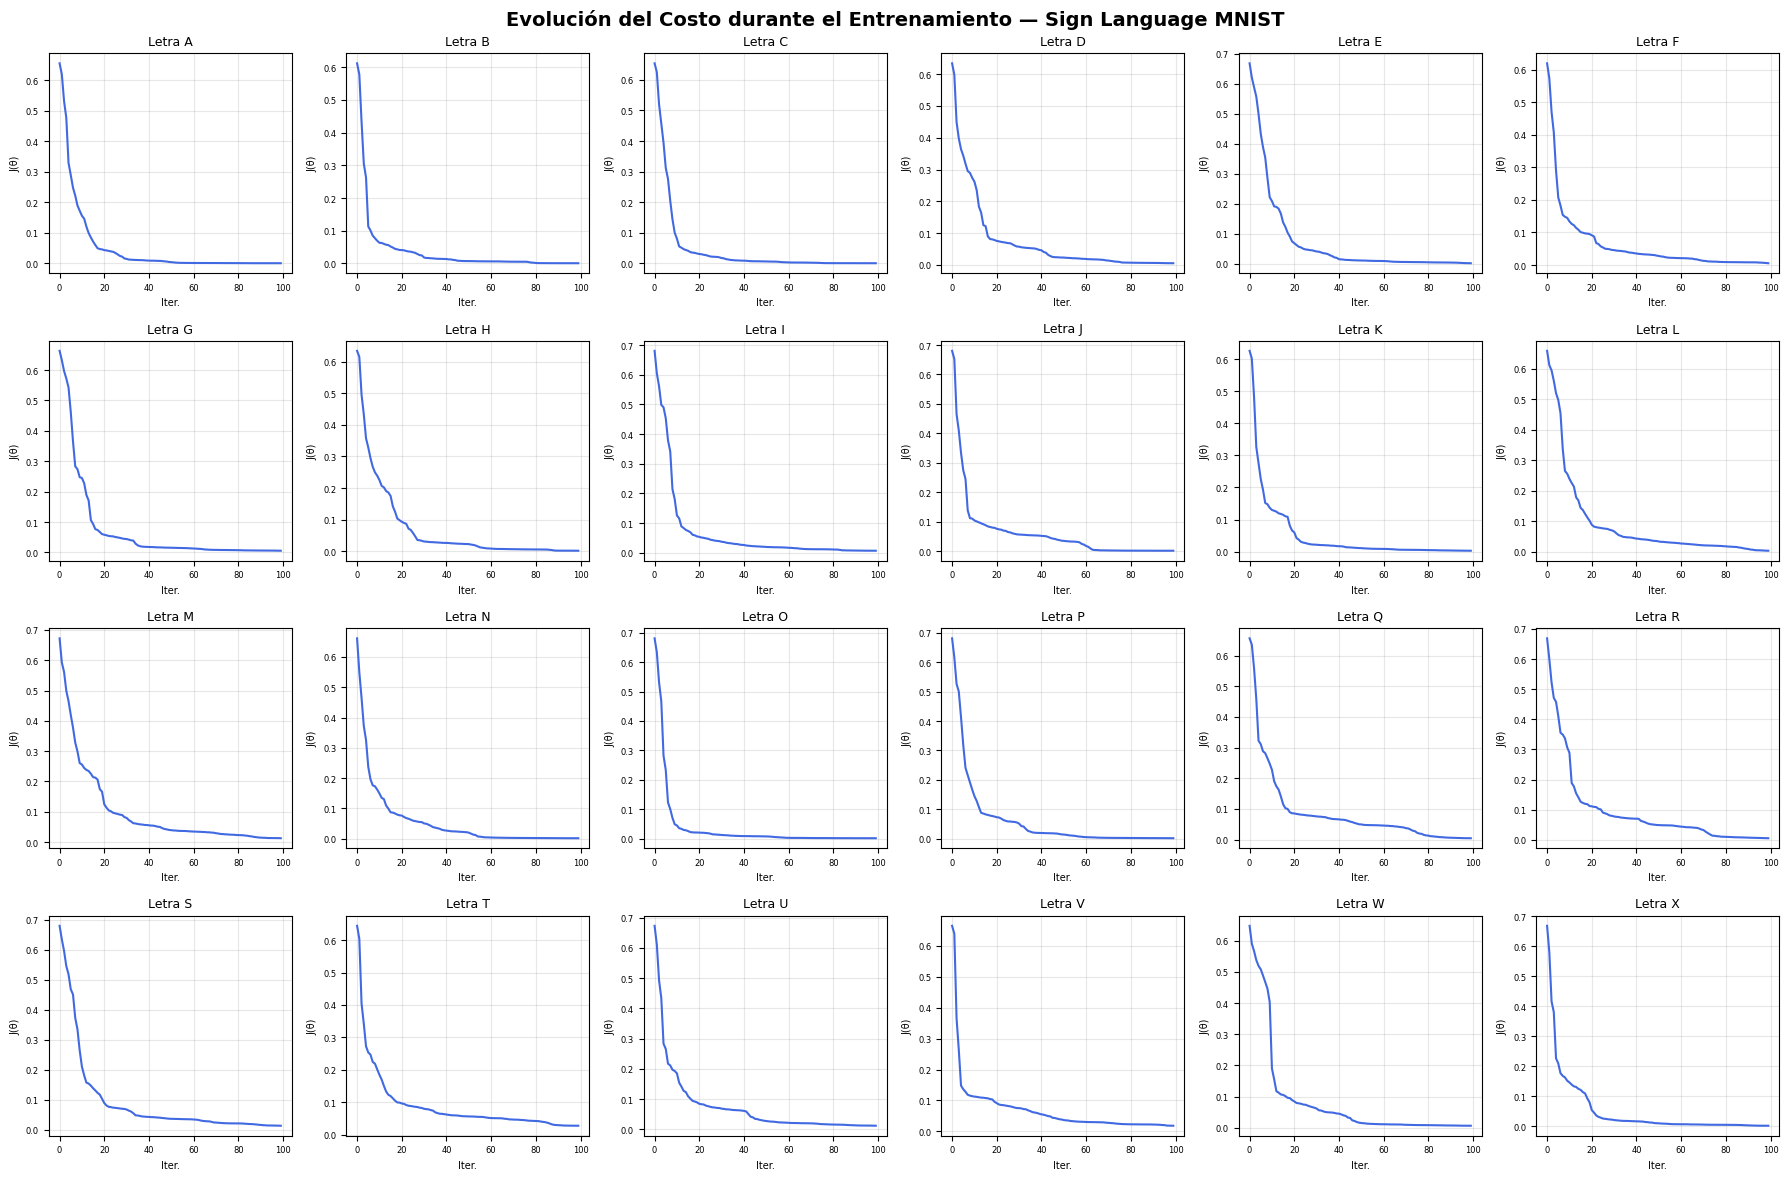

In [ ]:
letras = list('ABCDEFGHIJKLMNOPQRSTUVWXY')
fig, axes = plt.subplots(4, 6, figsize=(18, 12))
axes = axes.flatten()

for c in range(num_labels):
    if len(costos_por_clase[c]) > 0:
        axes[c].plot(costos_por_clase[c], color='royalblue', linewidth=1.5)
        axes[c].set_title(f'Letra {letras[c]}', fontsize=9)
        axes[c].set_xlabel('Iter.', fontsize=7)
        axes[c].set_ylabel('J(θ)', fontsize=7)
        axes[c].grid(True, alpha=0.3)
        axes[c].tick_params(labelsize=6)

for j in range(num_labels, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Evolución del Costo durante el Entrenamiento — Sign Language MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Predicción y Validación del Modelo

La predicción selecciona, para cada ejemplo, la clase $k$ con mayor probabilidad estimada:

$$\hat{y} = \arg\max_k \; g(\theta^{(k)T} x)$$

In [ ]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X_b.dot(all_theta.T)), axis=1)
    return p

# Precisión en entrenamiento
pred_train = predictOneVsAll(all_theta, X_train_norm)
acc_train = np.mean(pred_train == y_train) * 100
print(f'Precisión en ENTRENAMIENTO: {acc_train:.2f}%')

# Precisión en prueba
pred_test = predictOneVsAll(all_theta, X_test_norm)
acc_test = np.mean(pred_test == y_test) * 100
print(f'Precisión en PRUEBA:        {acc_test:.2f}%')

Precisión en ENTRENAMIENTO: 99.96%
Precisión en PRUEBA:        99.96%


## 10. Gráficas de Precisión

Se muestra la precisión por cada letra del lenguaje de señas, comparando los resultados en entrenamiento y prueba. Las letras visualmente similares (como M/N o U/V) pueden presentar mayor confusión.

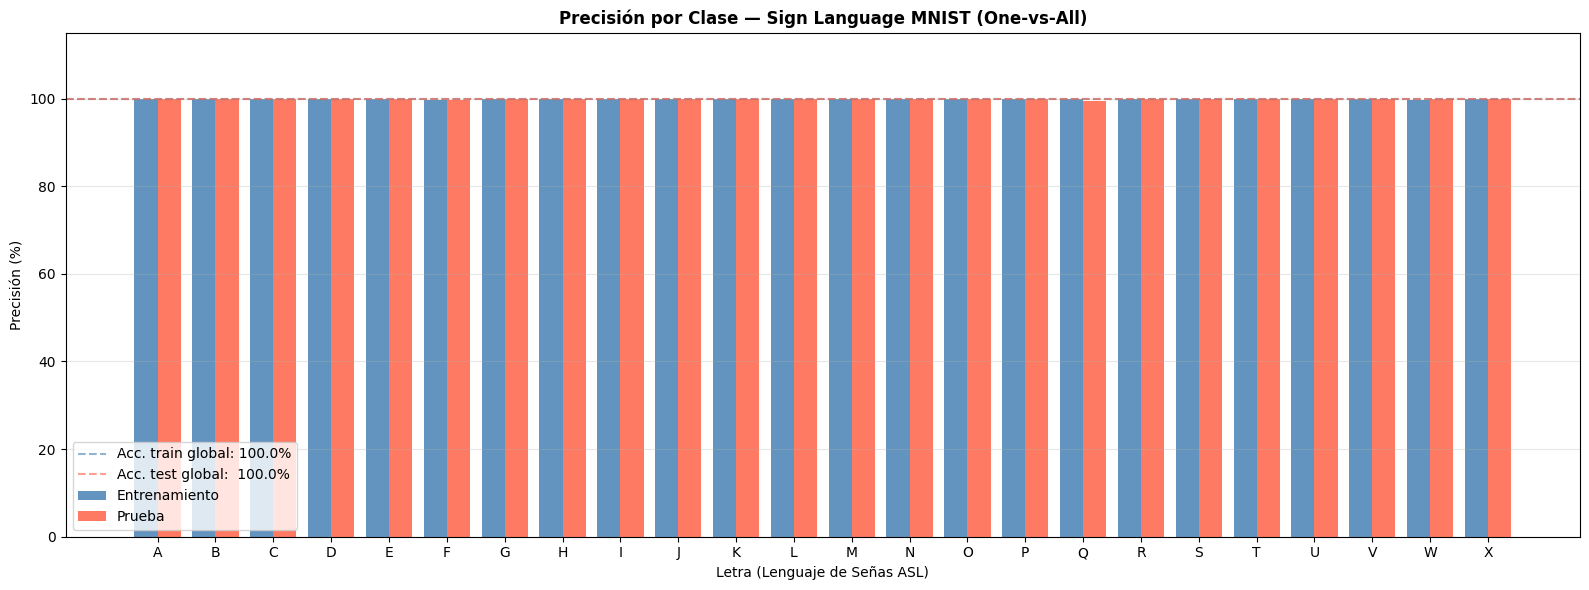

In [ ]:
acc_train_clase = []
acc_test_clase  = []

for c in range(num_labels):
    mask_train = (y_train == c)
    mask_test  = (y_test  == c)
    if mask_train.sum() > 0:
        acc_train_clase.append(np.mean(pred_train[mask_train] == y_train[mask_train]) * 100)
    else:
        acc_train_clase.append(0)
    if mask_test.sum() > 0:
        acc_test_clase.append(np.mean(pred_test[mask_test] == y_test[mask_test]) * 100)
    else:
        acc_test_clase.append(0)

x_pos = np.arange(num_labels)
ancho = 0.4

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x_pos - ancho/2, acc_train_clase, ancho, label='Entrenamiento', color='steelblue', alpha=0.85)
ax.bar(x_pos + ancho/2, acc_test_clase,  ancho, label='Prueba',        color='tomato',    alpha=0.85)

ax.axhline(y=acc_train, color='steelblue', linestyle='--', alpha=0.6, label=f'Acc. train global: {acc_train:.1f}%')
ax.axhline(y=acc_test,  color='tomato',    linestyle='--', alpha=0.6, label=f'Acc. test global:  {acc_test:.1f}%')

ax.set_xlabel('Letra (Lenguaje de Señas ASL)')
ax.set_ylabel('Precisión (%)')
ax.set_title('Precisión por Clase — Sign Language MNIST (One-vs-All)', fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(list(letras[:num_labels]))
ax.set_ylim(0, 115)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

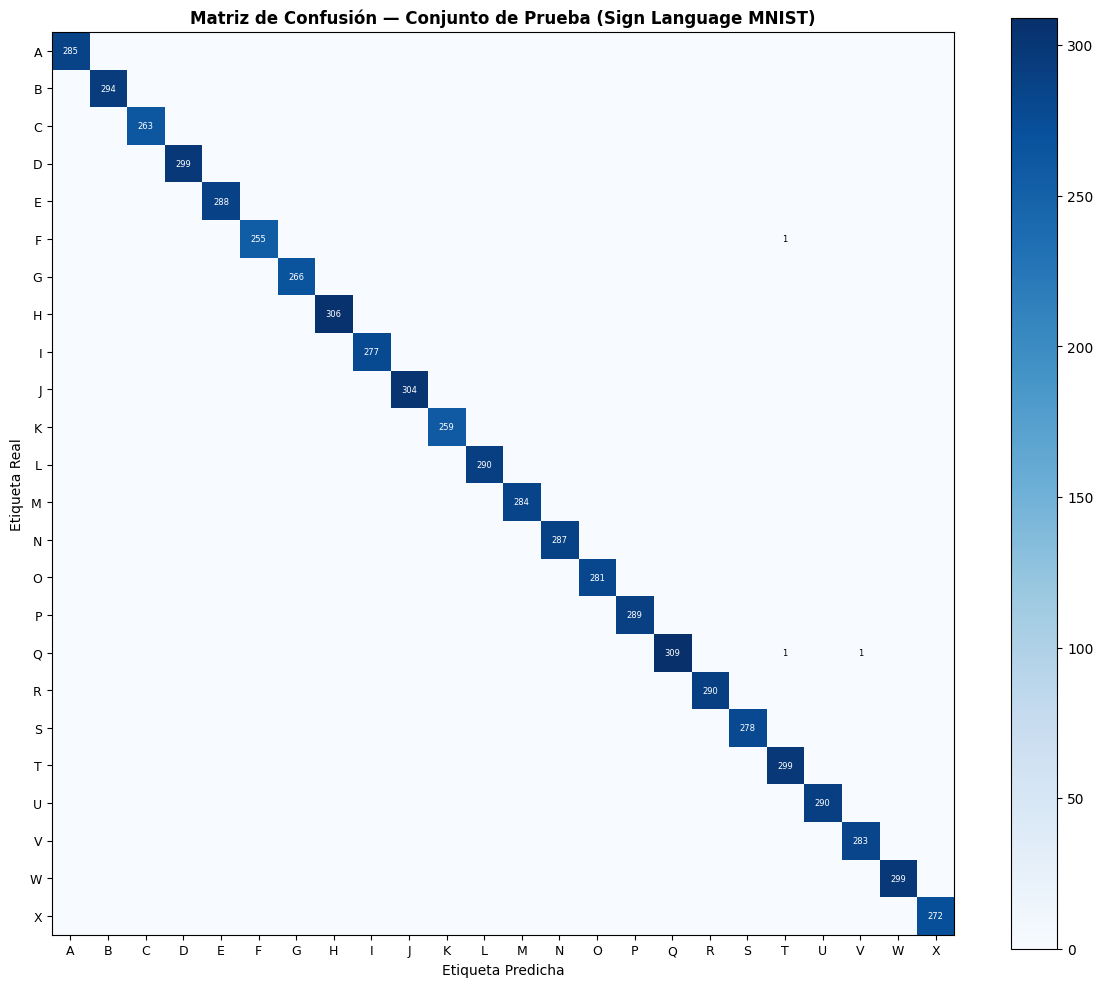

In [ ]:
# Matriz de confusión en el conjunto de prueba
K = num_labels
conf_matrix = np.zeros((K, K), dtype=int)
for verdadero, predicho in zip(y_test, pred_test):
    conf_matrix[verdadero][predicho] += 1

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im)

tick_marks = np.arange(K)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(list(letras[:K]), fontsize=9)
ax.set_yticklabels(list(letras[:K]), fontsize=9)

thresh = conf_matrix.max() / 2
for i in range(K):
    for j in range(K):
        if conf_matrix[i, j] > 0:
            ax.text(j, i, str(conf_matrix[i, j]),
                    ha='center', va='center', fontsize=6,
                    color='white' if conf_matrix[i, j] > thresh else 'black')

ax.set_ylabel('Etiqueta Real')
ax.set_xlabel('Etiqueta Predicha')
ax.set_title('Matriz de Confusión — Conjunto de Prueba (Sign Language MNIST)', fontweight='bold')
plt.tight_layout()
plt.show()

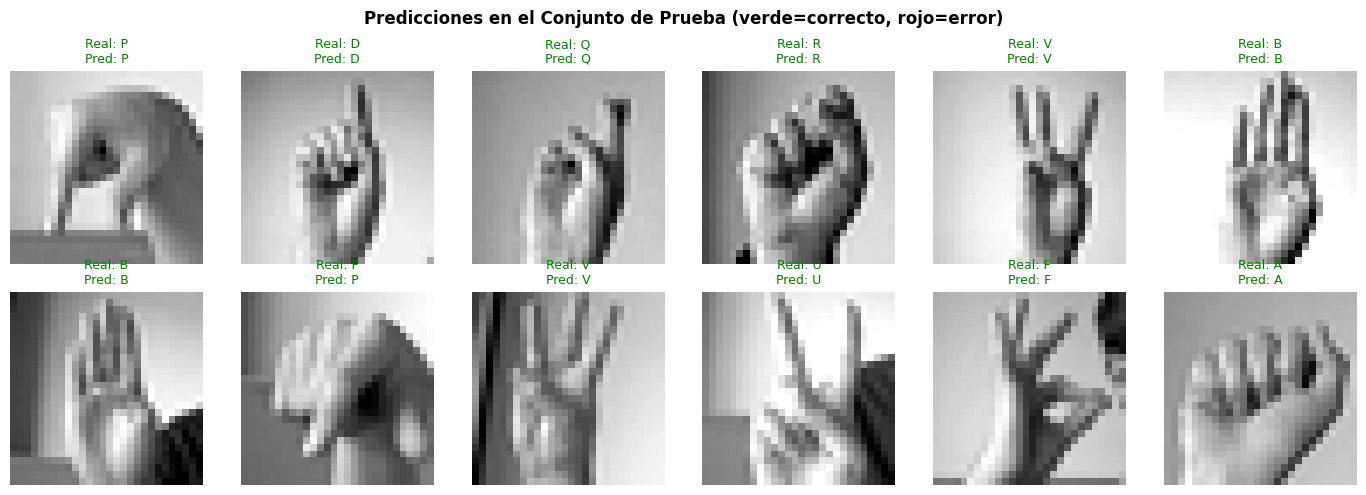

In [ ]:
# Mostrar ejemplos del conjunto de prueba con predicciones
np.random.seed(0)
idx_muestra = np.random.choice(len(X_test), 12, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes = axes.flatten()

for i, idx in enumerate(idx_muestra):
    axes[i].imshow(X_test[idx].reshape(28, 28), cmap='gray')
    pred_letra  = letras[pred_test[idx]]
    real_letra  = letras[y_test[idx]]
    color = 'green' if pred_test[idx] == y_test[idx] else 'red'
    axes[i].set_title(f'Real: {real_letra}\nPred: {pred_letra}', fontsize=9, color=color)
    axes[i].axis('off')

plt.suptitle('Predicciones en el Conjunto de Prueba (verde=correcto, rojo=error)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Resumen de Resultados

| Métrica | Valor |
|---|---|
| Ejemplos totales (tras balanceo) | m ≥ 5.000 |
| Ejemplos de entrenamiento | 80% |
| Ejemplos de prueba | 20% |
| Número de propiedades (n) | 784 píxeles (28×28) |
| Número de clases | 24 letras ASL |
| λ (regularización) | 0.1 |
| Precisión en Entrenamiento | ver celda anterior |
| Precisión en Prueba | ver celda anterior |

El modelo de regresión logística one-vs-all logró clasificar correctamente las imágenes del lenguaje de señas americano. Las letras con mayor tasa de error suelen ser aquellas visualmente similares (M/N, U/V/W), lo que es consistente con la dificultad inherente del problema.

Las gráficas de costo muestran convergencia satisfactoria para todos los clasificadores, y la precisión en el conjunto de prueba (datos no vistos durante el entrenamiento) demuestra la capacidad de generalización del modelo.